<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Lesson7_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression
### Import necessary packages

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py # common package to interact with a dataset that is stored on an H5 file.
import scipy
from PIL import Image
from scipy import ndimage

## Problem statement
Dataset ("data.h5") contains:

* a training set of m_train images labeled as cat (y=1) or non-cat (y=0)
* a test set of m_test images labeled as cat or non-cat
* each image is of shape (num_px, num_px, 3) where 3 is for the 3 channels (RGB) (each image is square: height = num_px and width = num_px).\
Task is to build a simple image-classification algorithm that can correctly classify pictures as cat or non-cat.

# Overview dataset
### Create shortcut for path

In [85]:
import os
cwd= os.getcwd() # current working directory
path = os.path.join(cwd,'C:/Users/klimk/Downloads/')
# print (path)

## Load dataset

In [86]:
def load_dataset():
    file_name=  os.path.join(path , 'train_catvnoncat.h5')
    train_dataset = h5py.File(file_name, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    file_name=  os.path.join(path , 'test_catvnoncat.h5')
    test_dataset = h5py.File(file_name, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = ['non-cat','cat']

    Y_train = Y_train.reshape(-1,1)
    Y_test = Y_test.reshape(-1,1)

    return X_train, Y_train, X_test, Y_test, classes

In [87]:
X_train,Y_train, X_test, Y_test, classes = load_dataset()

In [88]:
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('Y_train.shape= ',Y_train.shape)
print ('Y_test.shape= ',Y_test.shape)

X_train.shape=  (209, 64, 64, 3)
X_test.shape=  (50, 64, 64, 3)
Y_train.shape=  (209, 1)
Y_test.shape=  (50, 1)


In [89]:
# YOUR_CODE.   get m_train, num_px and m_test
# START_CODE
m_train = X_train.shape[0]
num_px = X_train.shape[1]
m_test = X_test.shape[0]
# END_CODE

## Check result

In [90]:
print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)


## Expected output

`Number of training examples: m_train = 209`\
`Number of testing examples: m_test = 50`\
`Height/Width of each image: num_px = 64`\
`Each image is of size: (64, 64, 3)`

## Review some examples

y = [1], it's a 'cat' picture.


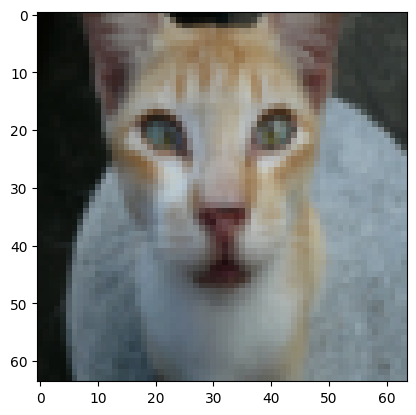

In [91]:
index = 11
plt.imshow(X_train[index])
print ("y = " + str(Y_train[index,:]) + ", it's a '" + classes[np.squeeze(Y_train[index,:])] +  "' picture.")

y = [0], it's a 'non-cat' picture.


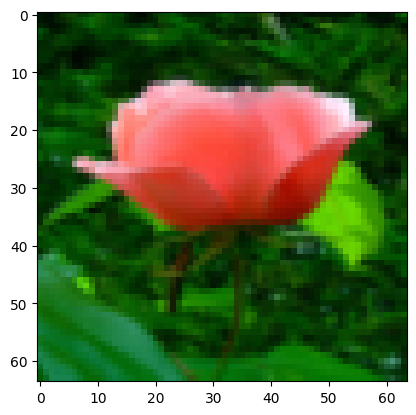

In [92]:
index = 3
plt.imshow(X_train[index])
print ("y = " + str(Y_train[index,:]) + ", it's a '" + classes[np.squeeze(Y_train[index,:])] +  "' picture.")

In [93]:
print ('Label 1 count:', np.sum(Y_train!=0))
print ('Label 0 count:', np.sum(Y_train==0))

Label 1 count: 72
Label 0 count: 137


## Flatten features

In [94]:
# YOUR_CODE. Reshape the training and test set to shape (number_of_samples,  num_px*num_px*3)
# START_CODE
X_train_flatten = X_train.reshape(X_train.shape[0], -1)
X_test_flatten = X_test.reshape(X_test.shape[0], -1)
# END_CODE

## Check result

In [95]:
print ("train_set_x_flatten shape: {}".format(X_train_flatten.shape))
print ("test_set_x_flatten shape: {}".format(X_test_flatten.shape))
print ("sanity check after reshaping: {}".format(X_train_flatten[0, :5]))

train_set_x_flatten shape: (209, 12288)
test_set_x_flatten shape: (50, 12288)
sanity check after reshaping: [17 31 56 22 33]


## Expected Output
`X_train_flattern shape: (209,12288)`\
`X_test_flattern shape: (50,12288)`\
`sanity check after reshaping: [17 31 56 22 33]`

# Normalize features
To represent color images, the red, green and blue channels (RGB) must be specified for each pixel, and so the pixel value is actually a vector of three numbers ranging from 0 to 255.\
For picture datasets, it is almost the same as MinMaxScaler to just divide every row of the dataset by 255 (the maximum value of a pixel channel).

In [96]:
X_train_scaled = X_train_flatten/255.
X_test_scaled = X_test_flatten/255.

# sigmoid function
$g(z) = \frac{1}{1+e^{-z}}$



In [97]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    g -- sigmoid(z)
    """

    # YOUR_CODE. Implement sigmoid function
    # START_CODE
    g = 1 / (1 + np.exp(-z))
    # END_CODE

    return g

## Check result

In [98]:
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


## Expected Output
`sigmoid([0, 2]) [0.5        0.88079708]`

# Initialize parameters

In [99]:
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (1,dim) for w and initializes b to 0.

    Argument:
    dim -- size of the w vector we want (or number of parameters in this case)

    Returns:
    w -- initialized vector of shape (1,dim)
    b -- initialized scalar (corresponds to the bias)
    """

    # YOUR_CODE.  Initialize b to zero and w as a vector of zeros.
    # START_CODE
    w = np.zeros((1, dim))
    b = 0
    # END_CODE

    assert(w.shape == (1,dim))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

## Check result

In [100]:
dim = 2
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0. 0.]]
b = 0


## Expected Output
`w =  [[ 0.  0.]]`\
`b = 0`

# Forward and Backward propagation
Computing cost function is called "forward" and computing derivatives (gradient) is called "backward" propagation\
**Forward Propagation:**
* compute $Z=b+X@w.T ([[z^{(0)}],[z^{(1)}],...,[z^{(m-1)}]])$
* compute $A=g(Z) ([[a^{(0)}],[a^{(1)}],...,[a^{(m-1)}]])$
* compute the cost function: $J= -\frac{1}{m}\sum_{i=0}^{m-1}(y^{(i)}log(a^{(i)})+(1-Y^{(i)})log(1-a^{(i)}))$

**Backward Propagation:**

$\frac{\partial J}{\partial w}=\frac{1}{m}(A-Y)^T@X$
&nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp;
$\frac{\partial J}{\partial b}=\frac{1}{m}\sum_{i=1}^{m}(a^{(i)}-y^{(i)})$

In [101]:
def propagate(w, b, X, Y, C=1):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array of size (1,num_px * num_px * 3)
    b -- bias, a scalar
    X -- data of size (number of examples, num_px * num_px * 3)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (number of examples,1)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b

    """
    m = X.shape[0]

    # YOUR_CODE.  implement forward propagation
    # START_CODE
    Z = np.dot(X, w.T) + b
    A = sigmoid(Z)

    # Calculating the standard value (without regularization)
    cost_orig = - (1 / m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    # Add L2 regularization: (C/(2m)) * sum(w^2)
    reg_cost = (C / (2 * m)) * np.sum(np.square(w))
    cost = cost_orig + reg_cost

    # YOUR_CODE.  Implement Backward propahation
    # START_CODE
    dZ = A - Y
    dJ_dw_orig = (1 / m) * np.dot(dZ.T, X)
    # Add the derivative of the regularization term: (C/m)*w
    dJ_dw = dJ_dw_orig + (C / m) * w
    dJ_db = (1 / m) * np.sum(dZ)

   # END_CODE

    assert(dJ_dw.shape == w.shape)
    assert(dJ_db.dtype == float)
    assert(cost.dtype == float)

    grads = {"dJ_dw": dJ_dw,
             "dJ_db": dJ_db}

    return grads, cost

In [102]:
w, b, X, Y = np.array([[1., 2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]).T, np.array([[1,0,1]]).T
grads, cost = propagate(w, b, X, Y)
print ("dJ_dw = " + str(grads["dJ_dw"]))
print ("dJ_db = " + str(grads["dJ_db"]))
print ("cost = " + str(cost))

dJ_dw = [[1.33178935 3.06173906]]
dJ_db = 0.001455578136784208
cost = 6.6348786527278865


# Expected Output
`dJ_dw = [[1.33178935 3.06173906]]`\
`dJ_db = 0.001455578136784208`\
`cost = 6.6348786527278865`

# Optimization

In [103]:
def optimize(w, b, X, Y, num_iterations, learning_rate, C= 1, verbose = False):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights, a numpy array of size (1,num_px * num_px * 3)
    b -- bias, a scalar
    X -- data of size (number of examples, num_px * num_px * 3)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (number of examples,1)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps

    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    """

    costs = [] # keep history for plotting if necessary

    for i in range(num_iterations):


        # YOUR_CODE.  Call to compute cost and gradient
        # START_CODE
        grads, cost = propagate(w, b, X, Y, C)
        # END_CODE

        # Retrieve derivatives from grads
        dJ_dw = grads["dJ_dw"]
        dJ_db = grads["dJ_db"]

        # YOUR_CODE.  Update paramaters
        # START_CODE
        w = w - learning_rate * dJ_dw
        b = b - learning_rate * dJ_db
        # END_CODE

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

        # Print the cost every 100 training iterations
        if verbose and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    params = {"w": w,
              "b": b}

    grads = {"dJ_dw": dJ_dw,
             "dJ_db": dJ_db}

    return params, grads, costs

## Check result

In [104]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, verbose = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dJ_dw"]))
print ("db = " + str(grads["dJ_db"]))

w = [[ 0.08006006 -0.02399336]]
b = 1.9060971483059892
dw = [[0.62090316 1.19256883]]
db = 0.2084129285706479


## Expected Output

`w = [[ 0.08006006 -0.02399336]]`\
`b = 1.9060971483059892`\
`dw = [[0.62090316 1.19256883]]`\
`db = 0.2084129285706479`

# Predict
1. Calculate $\hat{Y}=A=g(b+X@w.T)$
2. Convert the entries of a into 0 (if activation <= 0.5) or 1 (if activation > 0.5), store the predictions in a vector Y_prediction. Try to avoid for loop but use vectorized way if possible.

In [105]:
def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w - weights, a numpy array of size (1,num_px * num_px * 3)
    b - bias, a scalar
    X - data of size (number of examples, num_px * num_px * 3)

    Returns:
    Y_prediction - a numpy array of shape (number of examples, 1) containing all predictions (0/1) for the examples in X
    '''
    m,n = X.shape
    assert (w.shape==(1,n))

    # YOUR_CODE.  Compute "A" predicting the probabilities of a cat being present in the picture
    # START_CODE
    A= 1 / (1 + np.exp(- (np.dot(X, w.T) + b)))
    # END_CODE

    # YOUR_CODE.  Convert probabilities to actual predictions 0 or 1
    # START_CODE
    Y_prediction = (A > 0.5).astype(int)
    # END_CODE

    assert(Y_prediction.shape == (m, 1))

    return Y_prediction

## Check result

In [106]:
w = np.array([[0.1124579],[0.23106775]]).T
b = -0.3
X = np.array([[1.,-1.1,-3.2],[1.2,2.,0.1]]).T
print ("predictions = \n{}".format (predict(w, b, X)))

predictions = 
[[1]
 [1]
 [0]]


## Expected Output
`predictions=
[[1]
 [1]
 [0]]`

# Model

In [107]:
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, verbose = False, C= 1):
    """
    Builds the logistic regression model by calling the functions implemented previously

    Arguments:
    X_train -- training set represented by a numpy array of shape (number of examples, num_px * num_px * 3)
    Y_train -- training labels represented by a numpy array (vector) of shape (1, m_train)
    X_test -- test set represented by a numpy array of shape (num_px * num_px * 3, m_test)
    Y_test -- test labels represented by a numpy array (vector) of shape (number of examples,1)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to true to print the cost every 100 iterations
    C- regularization parameter

    Returns:
    res -- dictionary containing information about the model.
    """

    # YOUR_CODE.
    # START_CODE

    #  initialize parameters
    dim = X_train.shape[1]
    w, b = initialize_with_zeros(dim)

    # run gradient descent
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, C, verbose)


    # retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]

    # predict test/train set examples
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    # END_CODE

    # Print train/test Errors
    print("train accuracy= {:.3%}".format(np.mean(Y_prediction_train == Y_train)))
    print("test accuracy= {:.3%}".format(np.mean(Y_prediction_test == Y_test)))

    res = {'costs': costs,
           'Y_prediction_test': Y_prediction_test,
           'Y_prediction_train' : Y_prediction_train,
           'w' : w,
           'b' : b,
           'learning_rate' : learning_rate,
           'num_iterations': num_iterations,
           'C':C
          }

    return res

## Check result

In [108]:
res = model(X_train= X_train_scaled,
            Y_train=Y_train,
            X_test=X_test_scaled,
            Y_test= Y_test,
            num_iterations = 5000,
            learning_rate = 0.001,
            verbose = True,
            C= 0.3 # 0.6 is still overfitting,   0.3  is low value to keep the test accuracy ashigh as possible
           )

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.591297
Cost after iteration 200: 0.555819
Cost after iteration 300: 0.529019
Cost after iteration 400: 0.506946
Cost after iteration 500: 0.487970
Cost after iteration 600: 0.471225
Cost after iteration 700: 0.456191
Cost after iteration 800: 0.442526
Cost after iteration 900: 0.429989
Cost after iteration 1000: 0.418403
Cost after iteration 1100: 0.407635
Cost after iteration 1200: 0.397577
Cost after iteration 1300: 0.388144
Cost after iteration 1400: 0.379267
Cost after iteration 1500: 0.370886
Cost after iteration 1600: 0.362952
Cost after iteration 1700: 0.355423
Cost after iteration 1800: 0.348264
Cost after iteration 1900: 0.341442
Cost after iteration 2000: 0.334930
Cost after iteration 2100: 0.328703
Cost after iteration 2200: 0.322741
Cost after iteration 2300: 0.317024
Cost after iteration 2400: 0.311535
Cost after iteration 2500: 0.306259
Cost after iteration 2600: 0.301181
Cost after iteration 2700: 0.296290
Cost

# Expected Output
`train accuracy= 98.565%`\
`test accuracy= 70.000%`

# Visualize cost function changes

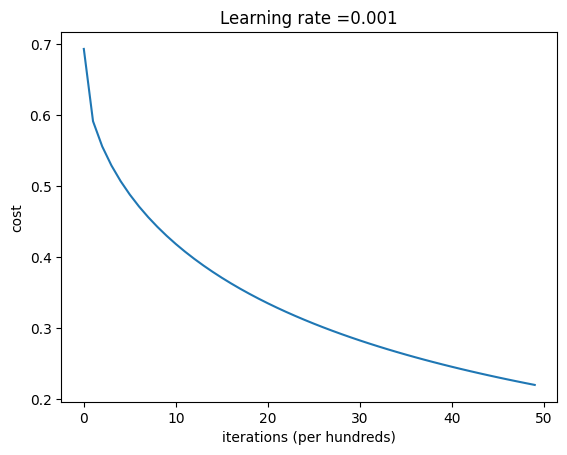

In [109]:
costs = np.squeeze(res['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(res["learning_rate"]))
plt.show()

# Visualize prediction

In [110]:
Y_test[index,0], res["Y_prediction_test"][index,0]

(1, 1)

y_predicted = 1 (true label = 1) , you predicted that it is a cat picture.


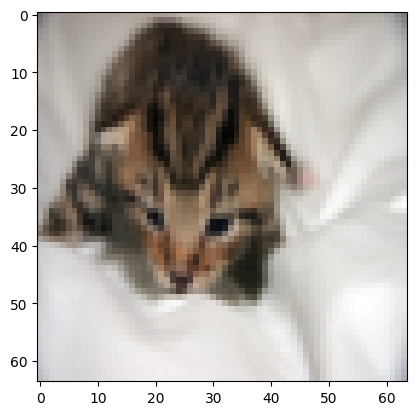

In [111]:
index = 1

plt.imshow(X_test[index,:].reshape(num_px, num_px, 3))
y_true = Y_test[index,0]
y_predicted =  res["Y_prediction_test"][index,0]
print ('y_predicted = {} (true label = {}) , you predicted that it is a {} picture.'.\
       format(y_predicted,
              y_true,
              classes[y_predicted]))

y_predicted = 0 (true label = 1) , you predicted that it is a non-cat picture.


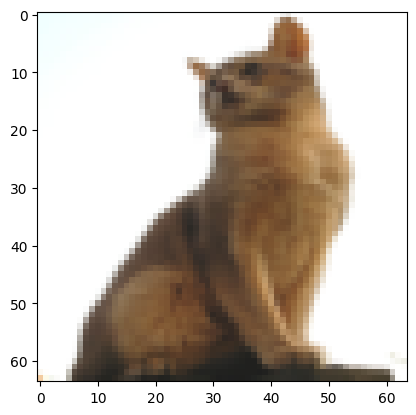

In [112]:
# index = 6 is example of a picture that was wrongly classified.
index = 6
plt.imshow(X_test[index,:].reshape(num_px, num_px, 3))
y_true = Y_test[index,0]
y_predicted =  res["Y_prediction_test"][index,0]
print ('y_predicted = {} (true label = {}) , you predicted that it is a {} picture.'.\
       format(y_predicted,
              y_true,
              classes[y_predicted]))

In [113]:
Y_test[index,0]

1

# Test with your image

image.size=  (64, 64)


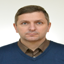

In [114]:
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/OleksiyTsebriy/Camp_2025/refs/heads/main/lesson_7_log_regr/data/Oleksiy.Tsebriy.jpg"

# Uploading an image with requests
response = requests.get(url)

# Open an image with BytesIO and resize it
image = Image.open(BytesIO(response.content)).resize((num_px, num_px))
print ('image.size= ', image.size)
image

In [115]:
my_image= np.array(image.getdata())
my_image.shape

(4096, 3)

In [116]:
my_image= my_image.reshape((1, num_px*num_px*3))
print ('my_image.shape=',my_image.shape)
my_image

my_image.shape= (1, 12288)


array([[227, 227, 217, ...,  43,  65,  96]])

In [117]:
my_predicted_image = predict(res["w"], res["b"], my_image)
my_predicted_image
print('y = {} , your algorithm predicts a {} picture.'.
      format(np.squeeze(my_predicted_image),classes[np.squeeze(my_predicted_image)]))

y = 0 , your algorithm predicts a non-cat picture.


C:\Users\klimk\AppData\Local\Temp\ipykernel_6540\2321409458.py:18: RuntimeWarning: overflow encountered in exp
  A= 1 / (1 + np.exp(- (np.dot(X, w.T) + b)))


image.size=  (64, 64)


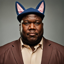

In [118]:
url = "https://images.nightcafe.studio/jobs/3BQ4YZAdhqWwV3BOh4GS/3BQ4YZAdhqWwV3BOh4GS--1--j44kd.jpg"

response = requests.get(url)

image = Image.open(BytesIO(response.content)).resize((num_px, num_px))
print ('image.size= ', image.size)
image

In [119]:
my_image= np.array(image.getdata())
my_image.shape

my_image= my_image.reshape((1, num_px*num_px*3))
print ('my_image.shape=',my_image.shape)

my_predicted_image = predict(res["w"], res["b"], my_image)
my_predicted_image
print('y = {} , your algorithm predicts a {} picture.'.
      format(np.squeeze(my_predicted_image),classes[np.squeeze(my_predicted_image)]))

my_image.shape= (1, 12288)
y = 0 , your algorithm predicts a non-cat picture.


image.size=  (64, 64)


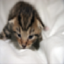

In [120]:
url = "https://github.com/OleksiyTsebriy/Camp_2025/blob/main/lesson_7_log_regr/data/test_cat.jpg?raw=true"

response = requests.get(url)

image = Image.open(BytesIO(response.content)).resize((num_px, num_px))
print ('image.size= ', image.size)
image

In [121]:
my_image= np.array(image.getdata())[:,:3]
print ('my_image.shape=', my_image.shape)
my_image= my_image.reshape((1, num_px*num_px*3))
print ('after reshape: my_image.shape=',my_image.shape)
my_predicted_image = predict(res["w"], res["b"], my_image)

print('y = {} , your algorithm predicts a {} picture.'.
      format(np.squeeze(my_predicted_image),classes[np.squeeze(my_predicted_image)]))

my_image.shape= (4096, 3)
after reshape: my_image.shape= (1, 12288)
y = 1 , your algorithm predicts a cat picture.


# Sklearn implementation

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
y_train = np.squeeze(Y_train) # LogisticRegression requires 1d input for y
clf = LogisticRegression(C=0.01).fit(X_train_scaled, y_train)

In [124]:
print("train accuracy= {:.3%}".format(clf.score (X_train_scaled, y_train)))
y_test = np.squeeze(Y_test)
print("test accuracy= {:.3%}".format(clf.score (X_test_scaled, y_test)))

train accuracy= 90.909%
test accuracy= 66.000%


In [125]:
print('y = {} , sklearn algorithm predicts a {} picture.'.
      format(np.squeeze(clf.predict(my_image)),classes[np.squeeze(clf.predict(my_image))]))

y = 1 , sklearn algorithm predicts a cat picture.


# Sklearn for brest cancer dataset

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

In [127]:
# import load_breast_cancer and get the X_cancer, y_cancer
(X_cancer, y_cancer)= data.data, data.target

#  split to train and test using random_state = 0
X_train, X_test, y_train, y_test =  train_test_split(X_cancer, y_cancer, random_state=42)
#  train LogisticRegression classifier  for max_iter= 10000
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)

print('\nBreast cancer dataset')
print ('X_cancer.shape= {}'.format(X_cancer.shape))
print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))


Breast cancer dataset
X_cancer.shape= (569, 30)
Accuracy of Logistic regression classifier on training set: 0.96
Accuracy of Logistic regression classifier on test set: 0.97


## Expected Output
`Breast cancer dataset`\
`X_cancer.shape= (569, 30)`\
`Accuracy of Logistic regression classifier on training set: 0.96`\
`Accuracy of Logistic regression classifier on test set: 0.95`

# Sklearn for synthetic dataset
## Additional functions for visualization

In [128]:
%matplotlib notebook
%matplotlib inline

In [129]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.01,plot_symbol_size = 50, ax= None,  is_extended=True):

    '''
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later
    cmap_light = ListedColormap(colors_for_areas)




    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    plt.title(title)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )



def plot_data_logistic_regression(X,y,legend_loc= 1, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)

## Make classification

In [130]:
from sklearn.datasets import make_classification

Xc_2, yc_2= make_classification(n_samples=100,
                                n_features=2,
                                n_informative=2,
                                n_redundant=0,
                                random_state=2018,
                                n_clusters_per_class=1,
                                flip_y = 0.1,
                                class_sep = 0.8)

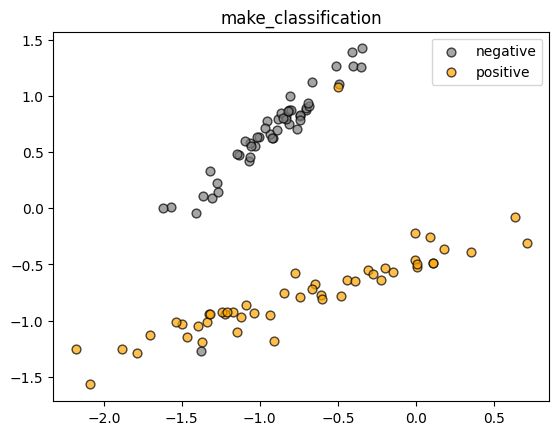

In [131]:
plt.figure()
plot_data_logistic_regression(Xc_2,yc_2,title= 'make_classification')

In [132]:
C = 1000
X_train, X_test, y_train, y_test = train_test_split(Xc_2, yc_2, random_state = 0)
clf = LogisticRegression(C=C).fit(X_train, y_train)
print('Make Regression')
print ('Xc_2.shape= {}'.format(Xc_2.shape))
print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Make Regression
Xc_2.shape= (100, 2)
Accuracy of Logistic regression classifier on training set: 0.99
Accuracy of Logistic regression classifier on test set: 0.92


Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)


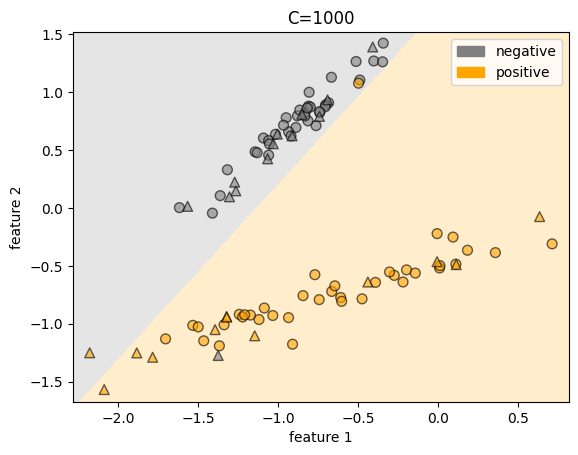

In [133]:
plt.figure()
plot_decision_boundary(clf, X_train, y_train, X_test, y_test, title='C={}'.format(C),precision=0.01, plot_symbol_size = 50)

Accuracy = 0.57
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)
Accuracy = 0.97
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)
Accuracy = 0.99
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)
Accuracy = 0.99
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)
Accuracy = 0.99
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)
Accuracy = 0.99
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)


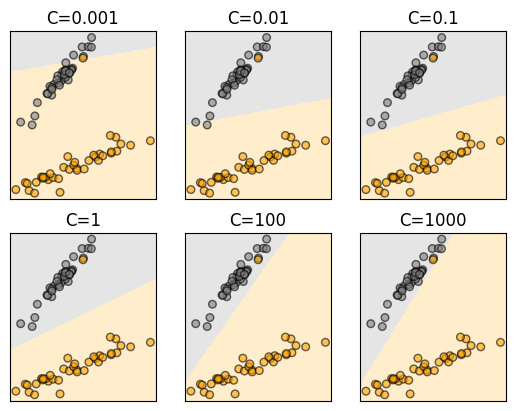

In [134]:
_, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3)
axes = (ax1, ax2, ax3, ax4, ax5, ax6)
C = (0.001, 0.01, 0.1, 1, 100, 1000)
for i in range (len(C)):
    clf = LogisticRegression(C=C[i]).fit(X_train, y_train)
    print('Accuracy = {:.2f}'.format(clf.score(X_train, y_train)))

    plot_decision_boundary(clf, X_train, y_train, title='C={}'.format(C[i]),precision=0.01, plot_symbol_size = 30, ax= axes[i], is_extended=False)


# Polynomial In Logistic Regression
## Additional functions for visualization

In [135]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True):

    '''
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later
    cmap_light = ListedColormap(colors_for_areas)




    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    plt.title(title)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )

def plot_decision_boundary_poly(clf, X_train, y_train, degree, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True):

    '''
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=degree,include_bias=False)

    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later
    cmap_light = ListedColormap(colors_for_areas)




    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    target_samples_grid_poly = poly.fit_transform(target_samples_grid)
    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid_poly)
    print ('Computing prediction completed.')
    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    plt.title(title)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )




def plot_data_logistic_regression(X,y,legend_loc= None, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)

def plot_multi_class_logistic_regression(X,y,dict_names=None, colors= None,  title =None):
    '''
    Draw the multi class samples of 2 features
    :param X: X 2 ndarray (m,2),
    :param y: vector (m,)
    :param dict_names: dict of values of y and names
    :return: None
    '''
    if not colors:
        colors_for_points = ['green','grey', 'orange', 'brown']
    else:
         colors_for_points = colors

    y_unique = list(set(y))

    for i in range (len(y_unique)):
        ind = y == y_unique[i] # vector

        if dict_names:
            plt.scatter(X[ind,0], X[ind,1], c=colors_for_points[i], s=40, label=dict_names[y_unique[i]],edgecolor='black', alpha=.7)
        else:
            plt.scatter(X[ind, 0], X[ind, 1], s=40, c=colors_for_points [i], edgecolor = 'black', alpha = 0.7)
    if title:
        plt.title(title)

    if dict_names:
        plt.legend(frameon=True)

def draw_linear_decision_boundaries_multiclass(clf,X,):
    colors=  ['green','grey', 'orange', 'brown']
    x_line = np.linspace(X[:,0].min(),X[:,0].max(), 100)
    for w, b, color in zip(clf.coef_, clf.intercept_, colors):
        # Since class prediction with a linear model uses the formula y = w_0 x_0 + w_1 x_1 + b,
        # and the decision boundary is defined as being all points with y = 0, to plot x_1 as a
        # function of x_0 we just solve w_0 x_0 + w_1 x_1 + b = 0 for x_1:
        y_line = -(x_line  * w[0] + b) / w[1]
        ind = (X[:,0].min()< x_line) & (x_line <X[:,0].max()) & (X[:,1].min()< y_line) & (y_line <X[:,1].max() )
        plt.plot(x_line[ind] , y_line[ind], '-', c=color, alpha=.8)

In [136]:
from sklearn.datasets import make_blobs

In [137]:
X_mk8, y_mk8 = make_blobs(n_samples = 200, n_features = 2, centers = 8, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
y_train = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

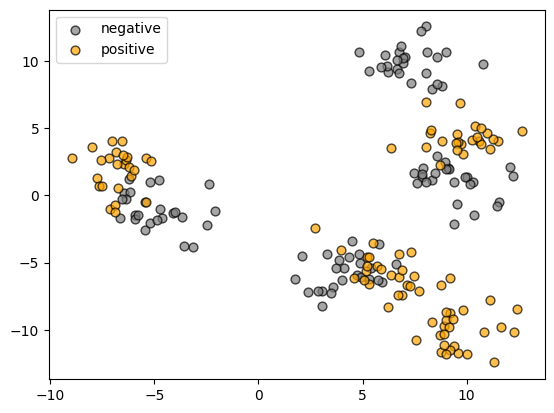

In [138]:
plt.figure()
plot_data_logistic_regression(X_mk8,y_train)

## Polynomial Features

In [139]:
from sklearn.preprocessing import PolynomialFeatures

In [140]:
degree = 10
poly= PolynomialFeatures(degree=degree,include_bias=False) # default is True means to return the first feature of all 1 as for degree 0
X_train_poly= poly.fit_transform(X_mk8)

In [141]:
C = 0.01
clf = LogisticRegression(C=C).fit(X_train_poly, y_train)
accuracy = clf.score (X_train_poly, y_train)
# print("train accuracy= {:.3%}".format(accuracy))

C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Computing prediction completed.


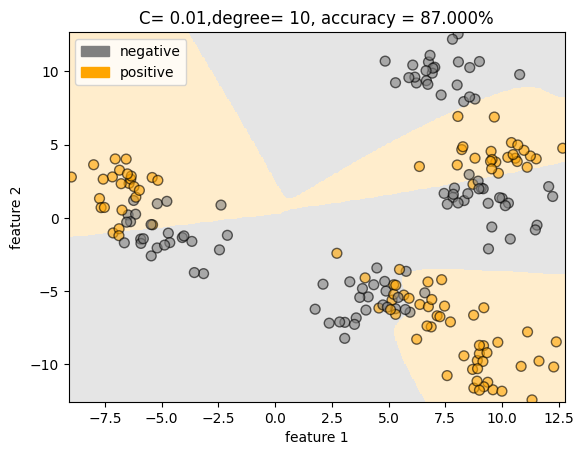

In [142]:
plt.figure()
ax = plt.gca()
plot_decision_boundary_poly(clf, X_train_poly, y_train, degree= degree, ax = ax, precision= 0.05, title = 'C= {},degree= {}, accuracy = {:.3%}'.format(C, degree, accuracy))

# Muticlass classification
## Load fruits data set

In [190]:
# cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table('https://raw.githubusercontent.com/OleksiyTsebriy/Camp_2025/refs/heads/main/lesson_7_log_regr/data/fruit_data_with_colors.txt')
X = df_fruits[['width', 'height']].values
y = df_fruits['fruit_label'].values
df_fruits.head(20)

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [191]:
fruits_dict = dict(zip(df_fruits['fruit_label'].unique(), df_fruits['fruit_name'].unique()))
fruits_dict

{1: 'apple', 2: 'mandarin', 3: 'orange', 4: 'lemon'}

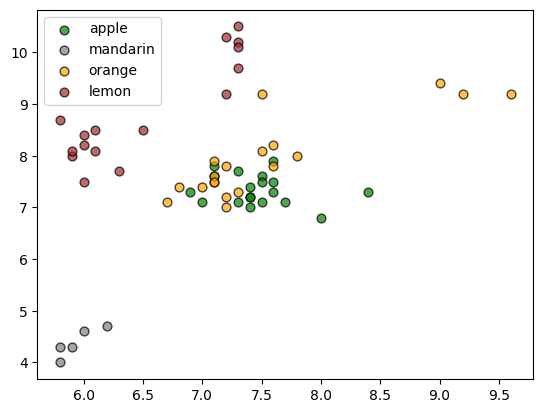

In [192]:
plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)

In [151]:
# help(LogisticRegression)

Accuracy=0.7288135593220338
Call prediction for all grid values (precision of drawing = 0.01,
 you may configure to speed up e.g. precision=0.05)


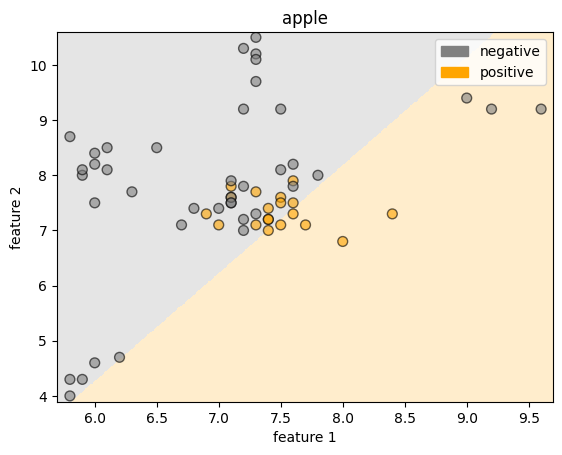

In [193]:
fruit_label = 1
y_one_vs_all = y==fruit_label
y_one_vs_all = y_one_vs_all.astype(int)

clf = LogisticRegression(C=1000).fit (X, y_one_vs_all)
print ('Accuracy={}'. format (clf.score(X,y_one_vs_all)))
plt.figure()
plot_decision_boundary(clf, X, y_one_vs_all, title=fruits_dict[fruit_label], precision = 0.01)

## Sklearn multiclass classificcation

In [187]:
print ('set(y) = {}'.format (set(y)))
print ('X.shape= {}\ny.shape = {}, '.format (X.shape, y.shape))
clf= LogisticRegression(C=1000, max_iter=2000).fit(X, y)
print ('Accuracy={}'. format (clf.score(X,y)))
clf.intercept_, clf.coef_

set(y) = {1, 2, 3, 4}
X.shape= (59, 2)
y.shape = (59,), 
Accuracy=0.847457627118644


(array([-20.53789848,  12.93246821, -32.45498071,  40.06041099]),
 array([[  6.66802311,  -2.96325149],
        [  5.74047714,  -7.76307328],
        [  4.36105881,   0.86735247],
        [-16.76955906,   9.8589723 ]]))

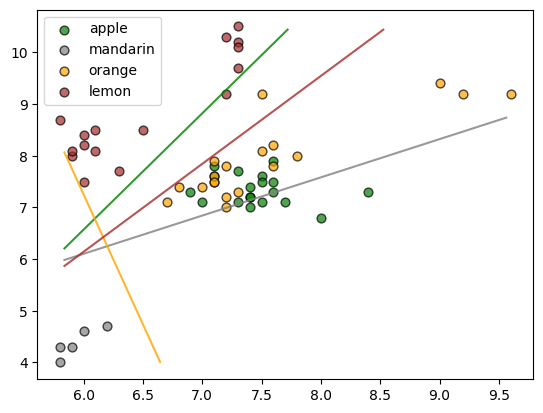

In [188]:
plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)
draw_linear_decision_boundaries_multiclass(clf,X)

C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy on training set: 0.84
Accuracy on test set: 0.80

Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.50      0.57         4
           2       1.00      1.00      1.00         2
           3       0.60      0.75      0.67         4
           4       1.00      1.00      1.00         5

    accuracy                           0.80        15
   macro avg       0.82      0.81      0.81        15
weighted avg       0.80      0.80      0.80        15



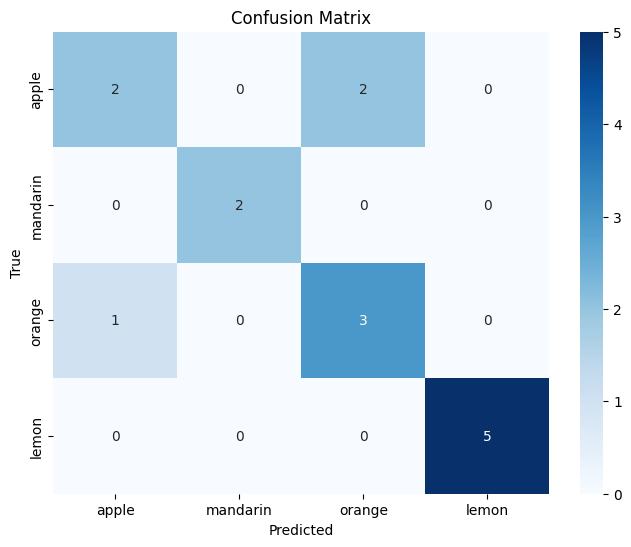

In [225]:
import seaborn as sns

df_fruits = pd.read_table('https://raw.githubusercontent.com/OleksiyTsebriy/Camp_2025/refs/heads/main/lesson_7_log_regr/data/fruit_data_with_colors.txt')
X = df_fruits[['width', 'height', 'mass', 'color_score']].values
y = df_fruits['fruit_label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Creating and training a multi-class logistic regression classifier
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight='balanced', max_iter=10000)
clf.fit(X_train, y_train)

# Model forecasting and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Create a mapping from fruit_label to fruit_name
label_to_name = df_fruits[['fruit_label', 'fruit_name']].drop_duplicates().set_index('fruit_label')['fruit_name'].to_dict()
# Get a list of fruit names in ascending numeric order
tick_labels = [label_to_name[i] for i in sorted(label_to_name.keys())]

print('Accuracy on training set: {:.2f}'.format(accuracy_score(y_train, y_train_pred)))
print('Accuracy on test set: {:.2f}'.format(accuracy_score(y_test, y_test_pred)))
print('\nClassification Report:\n', classification_report(y_test, y_test_pred))

# Building a confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Iris dataset

In [227]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y, labels = iris.data, iris.target, iris.target_names
print (labels)
clf= LogisticRegression(C=100, max_iter=2000).fit(X, y)
print ('Accuracy={}'. format (clf.score(X,y)))
clf.intercept_, clf.coef_

['setosa' 'versicolor' 'virginica']
Accuracy=0.98


(array([  1.9159118 ,  13.46070841, -15.37662021]),
 array([[ 2.50935285,  4.72836077, -6.73572747, -3.38760119],
        [-0.11239857, -0.23816484, -0.20063514, -4.32794113],
        [-2.39695428, -4.49019593,  6.93636261,  7.71554232]]))

Accuracy=0.8333333333333334
clf.intercept_=[ 25.20147565  -6.10573067 -19.09574498], 
clf.coef_=
[[-9.33492555  8.18440933]
 [ 3.72518971 -4.30410325]
 [ 5.60973584 -3.88030608]]


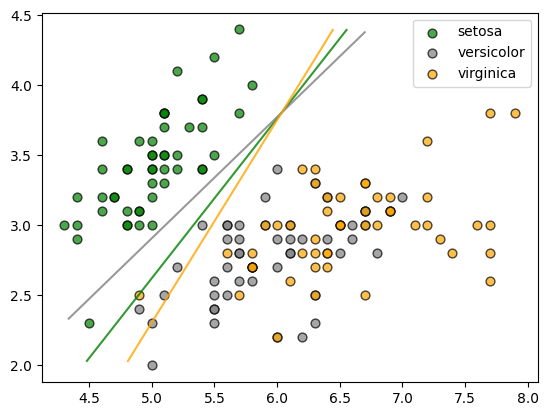

In [228]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
dict_names = {i:v for i,v in enumerate(labels)}

X2= X[:,:2]
clf= LogisticRegression(C=100).fit(X2, y)
print ('Accuracy={}'. format (clf.score(X2,y)))
print ('clf.intercept_={}, \nclf.coef_=\n{}'.format(clf.intercept_, clf.coef_))
plt.figure()
plot_multi_class_logistic_regression (X2,y, dict_names = dict_names)
draw_linear_decision_boundaries_multiclass(clf,X2)

Accuracy on training set: 0.96
Accuracy on test set: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


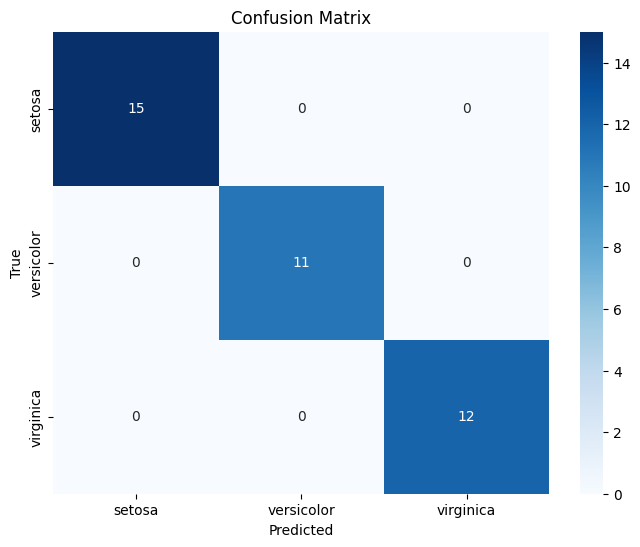

In [231]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Creating and training a multi-class logistic regression classifier
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight='balanced', max_iter=10000)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

print('Accuracy on training set: {:.2f}'.format(accuracy_score(y_train, y_train_pred)))
print('Accuracy on test set: {:.2f}'.format(accuracy_score(y_test, y_test_pred)))
print('\nClassification Report:\n', classification_report(y_test, y_test_pred))

# Building a confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()